Average roll: -89.21765543442177
Min roll: -108.72684619315858
Max roll: 0.0


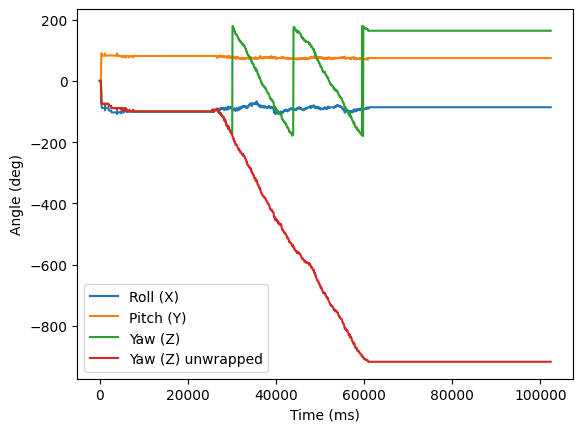

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def qmul(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

# def quat_to_euler_wxyz(q):
#     w,x,y,z = q
#     roll = np.degrees(np.arctan2(1 - 2*(x**2 + y**2), 2*(w*x + y*z)))
#     pitch = np.degrees(np.arcsin(np.clip(2*(w*y - z*x), -1.0, 1.0)))
#     yaw = np.degrees(np.arctan2(1 - 2*(y**2 + z**2), 2*(w*z + x*y)))
#     return roll, pitch, yaw

def quat_to_euler_wxyz(q):
    w, x, y, z = q
    # Roll (x-axis rotation)
    t0 = 2.0 * (w*x + y*z)
    t1 = 1.0 - 2.0 * (x*x + y*y)
    roll = np.degrees(np.arctan2(t0, t1))

    # Pitch (y-axis rotation)
    t2 = 2.0 * (w*y - z*x)
    t2 = np.clip(t2, -1.0, 1.0)
    pitch = np.degrees(np.arcsin(t2))

    # Yaw (z-axis rotation)
    t3 = 2.0 * (w*z + x*y)
    t4 = 1.0 - 2.0 * (y*y + z*z)
    yaw = np.degrees(np.arctan2(t3, t4))

    return roll, pitch, yaw

file_path = "logs/fal.csv"
df = pd.read_csv(file_path)
rpy = pd.DataFrame()
rpy["Timestamp"] = pd.to_datetime(df["Timestamp"])
rpy["ms"] = (rpy["Timestamp"] - rpy["Timestamp"].iloc[0]).dt.total_seconds() * 1000
q_map = np.array([0.5, 0.5, 0.5, 0.5])  #mapping new orientation of imu with transform quat

q_car = df.apply(lambda r: qmul(np.array([r.qw, r.qx, r.qy, r.qz]), q_map), axis=1)
q_car = np.vstack(q_car.values)

# convert to vehicle roll/pitch/yaw
#euler[["roll", "pitch", "yaw"]] = df.apply(lambda r: quat_to_euler(r.qw, r.qx, r.qy, r.qz), axis=1, result_type="expand")
roll, pitch, yaw = zip(*map(quat_to_euler_wxyz, q_car))
rpy["roll"]  = roll
rpy["pitch"] = pitch
rpy["yaw"]   = yaw
# yaw_rad = np.radians(euler["yaw"].to_numpy())
# euler["yaw_rel"] = np.degrees(np.unwrap(yaw_rad) - yaw_rad[0])

plt.plot(rpy["ms"], rpy["roll"], label="Roll (X)")
plt.plot(rpy["ms"], rpy["pitch"], label="Pitch (Y)")
plt.plot(rpy["ms"], rpy["yaw"], label="Yaw (Z)")

plt.xlabel("Time (ms)")
plt.ylabel("Angle (deg)")
print("Average roll:", rpy["roll"].mean())
print("Min roll:", rpy["roll"].min())
print("Max roll:", rpy["roll"].max())
yaw_unwrapped = np.unwrap(np.radians(rpy["yaw"]))
yaw_unwrapped = np.degrees(yaw_unwrapped)

plt.plot(rpy["ms"], yaw_unwrapped, label="Yaw (Z) unwrapped")
plt.legend()
plt.show()

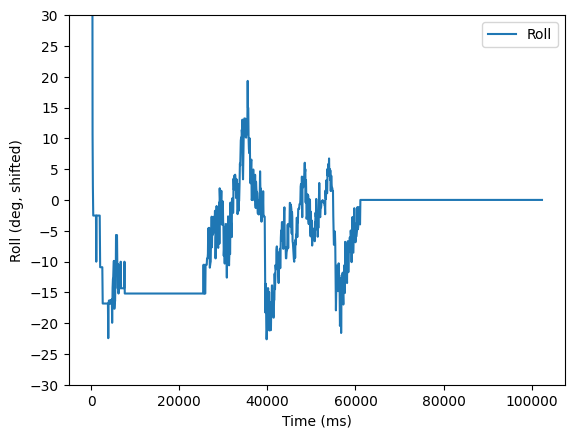

In [16]:
roll_shifted = rpy["roll"] - rpy["roll"].iloc[-1]

plt.figure()
plt.plot(rpy["ms"], roll_shifted, label="Roll")
plt.xlabel("Time (ms)")
plt.ylabel("Roll (deg, shifted)")
plt.locator_params(axis="y", nbins=15)
plt.ylim(-30, 30)
plt.legend()
plt.show()

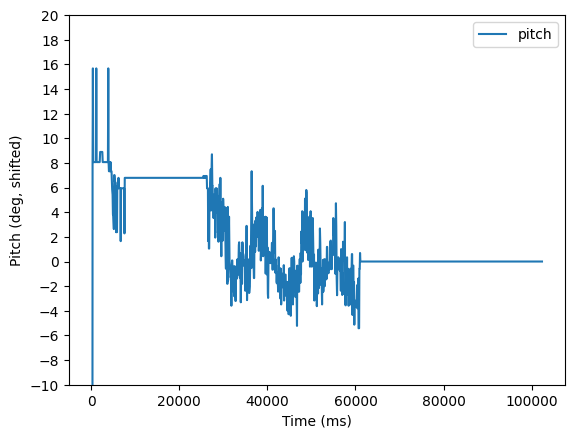

In [17]:
roll_shifted = rpy["pitch"] - rpy["pitch"].iloc[-1]

plt.figure()
plt.plot(rpy["ms"], roll_shifted, label="pitch")
plt.xlabel("Time (ms)")
plt.ylabel("Pitch (deg, shifted)")
plt.locator_params(axis="y", nbins=15)
plt.ylim(-10, 20)
plt.legend()
plt.show()

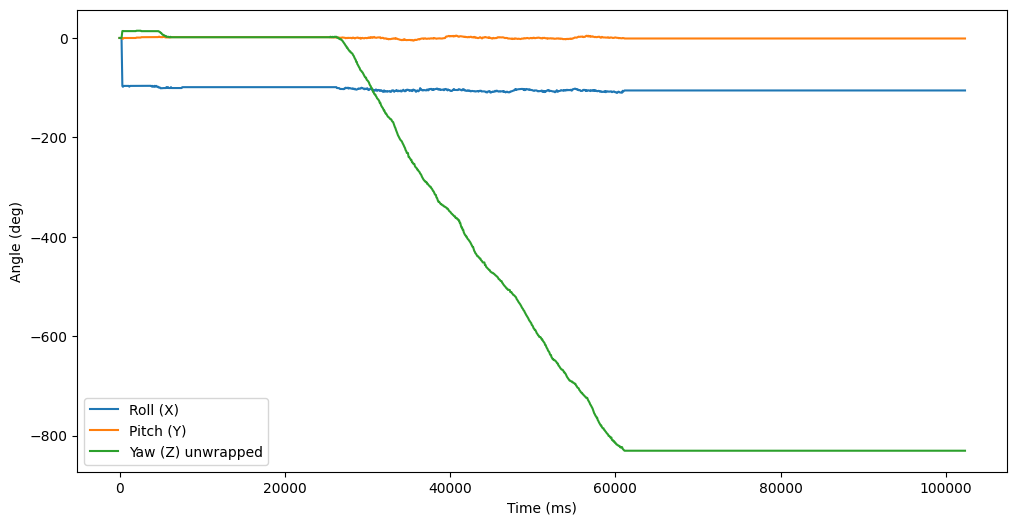

ax_car: min=-11.695, max=13.543, avg=-1.025
ay_car: min=-13.621, max=11.193, avg=0.201
az_car: min=-8.602, max=24.222, avg=9.130


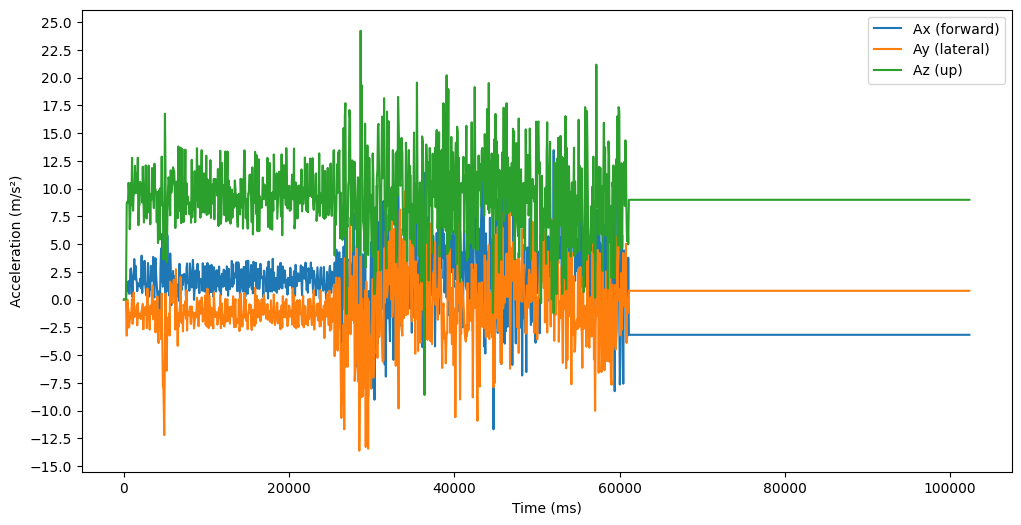

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


euler = pd.DataFrame()
euler["Timestamp"] = pd.to_datetime(df["Timestamp"])
euler["ms"] = (euler["Timestamp"] - euler["Timestamp"].iloc[0]).dt.total_seconds() * 1000


def qmul(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def q_conj(q):
    w, x, y, z = q
    return np.array([w, -x, -y, -z])

def quat_to_euler_wxyz(q):
    w, x, y, z = q
    # Roll
    t0 = 2.0 * (w*x + y*z)
    t1 = 1.0 - 2.0 * (x*x + y*y)
    roll = np.degrees(np.arctan2(t0, t1))
    # Pitch
    t2 = 2.0 * (w*y - z*x)
    t2 = np.clip(t2, -1.0, 1.0)
    pitch = np.degrees(np.arcsin(t2))
    # Yaw
    t3 = 2.0 * (w*z + x*y)
    t4 = 1.0 - 2.0 * (y*y + z*z)
    yaw = np.degrees(np.arctan2(t3, t4))
    return roll, pitch, yaw

def rotate_vector_by_quat(v, q):
    q_v = np.array([0, *v])
    q_out = qmul(qmul(q, q_v), q_conj(q))
    return q_out[1:]


q_map = np.array([0.5, 0.5, 0.5, 0.5])


roll_list, pitch_list, yaw_list = [], [], []
acc_vehicle = []

for i, r in df.iterrows():
    q_imu = np.array([r.qw, r.qx, r.qy, r.qz])

    roll, pitch, yaw = quat_to_euler_wxyz(q_imu)
    roll_list.append(roll)
    pitch_list.append(pitch)
    yaw_list.append(yaw)

    acc_raw = np.array([r.ax, r.ay, r.az])

    #  accel vector into world frame 
    acc_world = rotate_vector_by_quat(acc_raw, q_conj(q_imu))

    # remap to car
    acc_car = np.array([
        acc_world[2],   # forward
        acc_world[0],   # lateral
        acc_world[1]    # up
    ])
    acc_vehicle.append(acc_car)


euler["roll"]  = roll_list
euler["pitch"] = pitch_list
euler["yaw"]   = yaw_list

acc_vehicle = np.vstack(acc_vehicle)
euler["ax_car"], euler["ay_car"], euler["az_car"] = (
    acc_vehicle[:,0],
    acc_vehicle[:,1],
    acc_vehicle[:,2]
)


yaw_rad = np.radians(euler["yaw"])
yaw_unwrapped = np.unwrap(yaw_rad)
euler["yaw_rel"] = np.degrees(yaw_unwrapped - yaw_unwrapped[0])



plt.figure(figsize=(12,6))
plt.plot(euler["ms"], euler["roll"], label="Roll (X)")
plt.plot(euler["ms"], euler["pitch"], label="Pitch (Y)")
plt.plot(euler["ms"], euler["yaw_rel"], label="Yaw (Z) unwrapped")
plt.xlabel("Time (ms)")
plt.ylabel("Angle (deg)")
plt.legend()
plt.show()


plt.figure(figsize=(12,6))
plt.plot(euler["ms"], euler["ax_car"], label="Ax (forward)")
plt.plot(euler["ms"], euler["ay_car"], label="Ay (lateral)")
plt.plot(euler["ms"], euler["az_car"], label="Az (up)")
plt.locator_params(axis="y", nbins=20)
plt.xlabel("Time (ms)")
plt.ylabel("Acceleration (m/s²)")

for axis in ["ax_car", "ay_car", "az_car"]:
    values = euler[axis]
    print(
        f"{axis}: "
        f"min={values.min():.3f}, "
        f"max={values.max():.3f}, "
        f"avg={values.mean():.3f}"
    )

plt.legend()
plt.show()
